In [5]:
import sys, sklearn
print("Python executable:", sys.executable)
print("Python version:", sys.version)
print("scikit-learn:", sklearn.__version__)


Python executable: C:\Users\guerf\anaconda3\python.exe
Python version: 3.12.7 | packaged by Anaconda, Inc. | (main, Oct  4 2024, 13:17:27) [MSC v.1929 64 bit (AMD64)]
scikit-learn: 1.5.1


✅ Dataset chargé : (5479, 21) | 2010-01-01 00:00:00 -> 2024-12-31 00:00:00
✅ Split : train=4382 | test=1096

🚀 GridSearch : Ridge
Fitting 5 folds for each of 4 candidates, totalling 20 fits

🚀 GridSearch : DecisionTree
Fitting 5 folds for each of 36 candidates, totalling 180 fits

🚀 GridSearch : RandomForest
Fitting 5 folds for each of 16 candidates, totalling 80 fits

🚀 GridSearch : KNN
Fitting 5 folds for each of 100 candidates, totalling 500 fits
✅ Résultats (triés par MAE test)


,model,best_cv_mae,test_mae,test_rmse,test_r2,best_params
0,Ridge,1.820606,1.788374,2.362164,0.911669,{'model__alpha': 0.1}
2,RandomForest,1.867313,1.860902,2.439436,0.905796,"{'model__max_depth': 12, 'model__min_samples_l..."
3,KNN,2.028695,2.053467,2.666476,0.887445,"{'model__n_neighbors': 39, 'model__p': 1, 'mod..."
1,DecisionTree,2.092201,2.108957,2.695304,0.884998,"{'model__max_depth': 5, 'model__min_samples_le..."


✅ Meilleur modèle : Ridge
✅ Modèle sauvegardé -> best_model_t2mmax_nextday_2010_2024.pkl


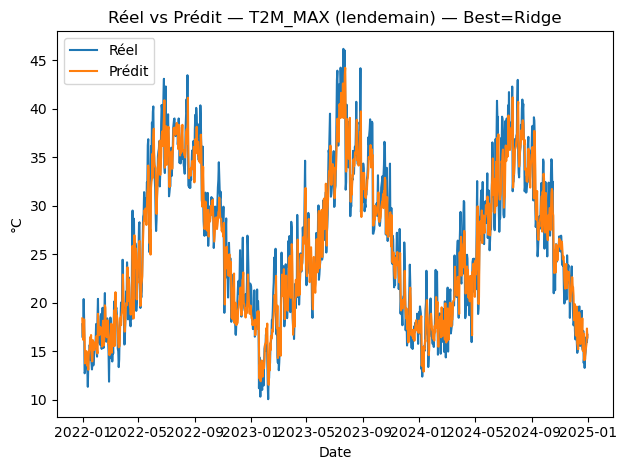

✅ Top importances (permutation)


T2M                  8.115148
T2M_MIN              1.106024
T2M_MAX_roll7        0.383673
T2M_MAX_lag1         0.369649
ALLSKY_SFC_SW_DWN    0.230613
WS2M                 0.111460
Type_de_jour         0.080667
saison               0.079706
PRECTOTCORR          0.002777
mois                 0.000327
jour_semaine         0.000220
Jour_de_gel          0.000000
annee               -0.000744
jour                -0.001240
PRECTOTCORR_roll7   -0.001275
dtype: float64

✅ Phase 3 terminée ✅


In [7]:
# ============================================================
# PHASE 3 — Modélisation Prédictive (MONOBLOC)
# Colle TOUT ce bloc dans UNE seule cellule puis exécute.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import joblib

from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)

FEAT_PATH  = "tunis_2010_2024_clean_features.csv"
MODEL_PATH = "best_model_t2mmax_nextday_2010_2024.pkl"

TRAIN_RATIO = 0.8
N_SPLITS_TSCV = 5
RANDOM_STATE = 42

def log_ok(msg):   print(f"✅ {msg}")
def log_warn(msg): print(f"⚠️ {msg}")
def log_err(msg):  print(f"❌ {msg}")

def assert_file_exists(path: str):
    # Vérifie que le fichier existe
    if not Path(path).exists():
        raise FileNotFoundError(f"Fichier introuvable: {path}")

def safe_read_csv(path: str, parse_dates=None):
    # Lecture robuste (utf-8-sig puis latin-1)
    assert_file_exists(path)
    try:
        return pd.read_csv(path, parse_dates=parse_dates, encoding="utf-8-sig")
    except UnicodeDecodeError:
        log_warn("UnicodeDecodeError -> fallback latin-1")
        return pd.read_csv(path, parse_dates=parse_dates, encoding="latin-1")

def require_columns(df: pd.DataFrame, cols: list, context: str):
    # Vérifie colonnes indispensables
    missing = [c for c in cols if c not in df.columns]
    if missing:
        raise ValueError(f"{context} : colonnes manquantes -> {missing}")

def build_nextday_target(df: pd.DataFrame) -> pd.DataFrame:
    # Cible "lendemain" : y_next(t) = T2M_MAX(t+1)
    require_columns(df, ["T2M_MAX"], "build_nextday_target")
    df = df.copy()
    df["y_next"] = df["T2M_MAX"].shift(-1)      # <-- ICI la cible lendemain
    df = df.dropna(subset=["y_next"]).reset_index(drop=True)
    return df

def build_ml_matrices(df: pd.DataFrame):
    # Construit X et y sans fuite :
    # - on retire date (index temporel)
    # - on retire T2M_MAX (valeur du jour) pour éviter fuite vers y_next
    # - on retire y_next de X
    require_columns(df, ["date", "T2M_MAX", "y_next"], "build_ml_matrices")
    X = df.drop(columns=["date", "T2M_MAX", "y_next"], errors="ignore").copy()
    y = df["y_next"].astype(float).copy()

    # Retirer colonnes techniques si elles existent
    for c in ["YEAR", "MO", "DY", "DOY", "PS"]:
        if c in X.columns:
            X = X.drop(columns=[c])

    return X, y

def split_time(df: pd.DataFrame, X: pd.DataFrame, y: pd.Series):
    # Split temporel 80/20 sans mélange
    split_idx = int(len(df) * TRAIN_RATIO)
    X_train = X.iloc[:split_idx].copy()
    X_test  = X.iloc[split_idx:].copy()
    y_train = y.iloc[:split_idx].copy()
    y_test  = y.iloc[split_idx:].copy()
    dates_test = df["date"].iloc[split_idx:].copy()
    return X_train, X_test, y_train, y_test, dates_test

def make_preprocessor(X: pd.DataFrame, scale_numeric: bool):
    # Préprocess :
    # - numériques : impute médiane + scaler si nécessaire
    # - catégorielles : impute mode + onehot
    num_cols = X.select_dtypes(include=["number"]).columns.tolist()
    cat_cols = X.select_dtypes(exclude=["number"]).columns.tolist()

    num_steps = [("imputer", SimpleImputer(strategy="median"))]
    if scale_numeric:
        num_steps.append(("scaler", StandardScaler()))
    num_pipe = Pipeline(steps=num_steps)

    cat_pipe = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ])

    pre = ColumnTransformer(
        transformers=[
            ("num", num_pipe, num_cols),
            ("cat", cat_pipe, cat_cols)
        ],
        remainder="drop"
    )
    return pre

def build_gridsearch_models(X_train: pd.DataFrame):
    # GridSearch + TimeSeriesSplit pour 4 modèles demandés
    tscv = TimeSeriesSplit(n_splits=N_SPLITS_TSCV)
    searches = {}

    # 1) Régression (Ridge)
    ridge_pipe = Pipeline([
        ("preprocess", make_preprocessor(X_train, scale_numeric=True)),
        ("model", Ridge(random_state=RANDOM_STATE))
    ])
    searches["Ridge"] = GridSearchCV(
        ridge_pipe,
        {"model__alpha": [0.1, 1.0, 10.0, 100.0]},
        scoring="neg_mean_absolute_error",
        cv=tscv, n_jobs=-1, verbose=1, refit=True
    )

    # 2) Arbre
    tree_pipe = Pipeline([
        ("preprocess", make_preprocessor(X_train, scale_numeric=False)),
        ("model", DecisionTreeRegressor(random_state=RANDOM_STATE))
    ])
    searches["DecisionTree"] = GridSearchCV(
        tree_pipe,
        {"model__max_depth": [None, 5, 10, 20],
         "model__min_samples_split": [2, 5, 10],
         "model__min_samples_leaf": [1, 2, 4]},
        scoring="neg_mean_absolute_error",
        cv=tscv, n_jobs=-1, verbose=1, refit=True
    )

    # 3) Forêt
    rf_pipe = Pipeline([
        ("preprocess", make_preprocessor(X_train, scale_numeric=False)),
        ("model", RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1))
    ])
    searches["RandomForest"] = GridSearchCV(
        rf_pipe,
        {"model__n_estimators": [300, 600],
         "model__max_depth": [None, 12],
         "model__min_samples_split": [2, 5],
         "model__min_samples_leaf": [1, 2]},
        scoring="neg_mean_absolute_error",
        cv=tscv, n_jobs=-1, verbose=1, refit=True
    )

    # 4) KNN
    knn_pipe = Pipeline([
        ("preprocess", make_preprocessor(X_train, scale_numeric=True)),
        ("model", KNeighborsRegressor())
    ])
    searches["KNN"] = GridSearchCV(
        knn_pipe,
        {"model__n_neighbors": list(range(3, 52, 2)),
         "model__weights": ["uniform", "distance"],
         "model__p": [1, 2]},
        scoring="neg_mean_absolute_error",
        cv=tscv, n_jobs=-1, verbose=1, refit=True
    )

    return searches

def compute_metrics(y_true, y_pred):
    # MAE / RMSE / R²
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2

def plot_real_vs_pred(dates, y_true, y_pred, title):
    # Plot réel vs prédit
    plt.figure()
    plt.plot(dates, y_true.values, label="Réel")
    plt.plot(dates, y_pred, label="Prédit")
    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel("°C")
    plt.legend()
    plt.tight_layout()
    plt.show()

def permutation_importance_model(best_pipe, X_test, y_test, top_n=15):
    # Importance permutation : fonctionne pour tous les modèles
    r = permutation_importance(
        best_pipe, X_test, y_test,
        n_repeats=10,
        random_state=RANDOM_STATE,
        scoring="neg_mean_absolute_error",
        n_jobs=-1
    )
    imp = pd.Series(r.importances_mean, index=X_test.columns).sort_values(ascending=False)
    log_ok("Top importances (permutation)")
    display(imp.head(top_n))
    return imp

def run_phase3():
    try:
        # 1) Charger le dataset features (Phase 1)
        df = safe_read_csv(FEAT_PATH, parse_dates=["date"]).sort_values("date").reset_index(drop=True)
        require_columns(df, ["date", "T2M_MAX"], "Phase 3")
        log_ok(f"Dataset chargé : {df.shape} | {df['date'].min()} -> {df['date'].max()}")

        # 2) Construire la cible "lendemain"
        df = build_nextday_target(df)

        # 3) Construire X et y
        X, y = build_ml_matrices(df)

        # 4) Split temporel
        X_train, X_test, y_train, y_test, dates_test = split_time(df, X, y)
        log_ok(f"Split : train={len(X_train)} | test={len(X_test)}")

        # 5) GridSearch sur les 4 modèles
        searches = build_gridsearch_models(X_train)

        rows = []
        for name, gs in searches.items():
            print("\n" + "="*70)
            print(f"🚀 GridSearch : {name}")
            print("="*70)

            # Entraînement CV temporelle
            gs.fit(X_train, y_train)

            # Meilleur modèle trouvé
            best_pipe = gs.best_estimator_

            # Prédiction sur test
            y_pred = best_pipe.predict(X_test)

            # Métriques
            mae, rmse, r2 = compute_metrics(y_test, y_pred)

            rows.append({
                "model": name,
                "best_cv_mae": -gs.best_score_,
                "test_mae": mae,
                "test_rmse": rmse,
                "test_r2": r2,
                "best_params": gs.best_params_
            })

        # 6) Résultats
        results = pd.DataFrame(rows).sort_values("test_mae")
        log_ok("Résultats (triés par MAE test)")
        display(results)

        # 7) Sélection du meilleur modèle
        best_name = results.iloc[0]["model"]
        best_model = searches[best_name].best_estimator_
        log_ok(f"Meilleur modèle : {best_name}")

        # 8) Sauvegarder le modèle (pipeline complet)
        joblib.dump(best_model, MODEL_PATH)
        log_ok(f"Modèle sauvegardé -> {MODEL_PATH}")

        # 9) Plot réel vs prédit (meilleur modèle)
        best_pred = best_model.predict(X_test)
        plot_real_vs_pred(dates_test, y_test, best_pred, f"Réel vs Prédit — T2M_MAX (lendemain) — Best={best_name}")

        # 10) Importance des variables
        permutation_importance_model(best_model, X_test, y_test, top_n=15)

        log_ok("Phase 3 terminée ✅")
        return best_model, results

    except Exception as e:
        log_err(f"Phase 3 échouée: {e}")
        raise

# --- Exécution (une seule ligne) ---
best_model, results_phase3 = run_phase3()
